<a href="https://colab.research.google.com/github/Nirtika123/Apallo-Handling-Missing-Values-and-Outliers/blob/main/da_lab3(22_7).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Import the required Python libraries.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Task 2: Load `patient_health_screening.csv` into a DataFrame.

In [ ]:
data=pd.read_csv('patient_health_screening.csv')
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level
0,PAT001,58,Male,150.9,63.7,119.0,73.0,64.0,161.0,239.0,28.0,Current,Low
1,PAT002,45,Male,151.0,60.5,137.0,66.0,93.0,100.0,236.0,26.5,Former,Moderate
2,PAT003,32,Female,NaN,94.1,105.0,75.0,102.0,129.0,188.0,32.3,Never,Low
3,PAT004,220,Female,153.6,69.7,127.0,87.0,96.0,108.0,248.0,29.5,Never,Moderate
4,PAT005,25,Female,152.8,64.7,145.0,88.0,94.0,99.0,235.0,27.7,Never,Moderate


Task 3: Display the shape of the dataset.

In [ ]:
data.shape

(50, 13)

Task 4: Display the column names, non-null counts, and data types.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               50 non-null     object 
 1   Age                      50 non-null     int64  
 2   Gender                   50 non-null     object 
 3   Height_cm                48 non-null     float64
 4   Weight_kg                48 non-null     float64
 5   Systolic_BP              48 non-null     float64
 6   Diastolic_BP             49 non-null     float64
 7   Heart_Rate               49 non-null     float64
 8   Blood_Glucose_mg_dL      48 non-null     float64
 9   Cholesterol_mg_dL        48 non-null     float64
 10  BMI                      49 non-null     float64
 11  Smoking_Status           48 non-null     object 
 12  Physical_Activity_Level  49 non-null     object 
dtypes: float64(8), int64(1), object(4)
memory usage: 5.2+ KB


Task 5: Generate descriptive statistics for the numerical columns.

In [ ]:
data.describe()

,Age,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI
count,50.000000,48.000000,48.000000,48.000000,49.000000,49.000000,48.000000,48.000000,49.000000
mean,54.240000,165.441667,81.554167,130.270833,81.061224,87.346939,125.729167,219.125000,31.814286
std,30.030298,16.207259,30.619872,28.537948,15.547519,26.745366,50.535742,55.339427,16.746890
min,21.000000,98.000000,31.000000,72.000000,65.000000,38.000000,75.000000,148.000000,9.200000
25%,35.500000,154.975000,62.750000,114.500000,73.000000,76.000000,98.500000,178.500000,22.300000
50%,52.000000,164.700000,75.450000,123.500000,77.000000,85.000000,115.500000,227.500000,28.100000
75%,67.000000,174.100000,98.550000,145.250000,88.000000,96.000000,142.750000,243.000000,34.500000
max,220.000000,212.000000,245.000000,285.000000,165.000000,245.000000,420.000000,510.000000,102.000000


Task 6: Count the missing values in each column.

In [ ]:
data.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Height_cm,2
Weight_kg,2
Systolic_BP,2
Diastolic_BP,1
Heart_Rate,1
Blood_Glucose_mg_dL,2
Cholesterol_mg_dL,2


Task 7: Calculate the percentage of missing values in each column.

In [ ]:
(data.isnull().mean()*100).round(2)

,0
Patient_ID,0.0
Age,0.0
Gender,0.0
Height_cm,4.0
Weight_kg,4.0
Systolic_BP,4.0
Diastolic_BP,2.0
Heart_Rate,2.0
Blood_Glucose_mg_dL,4.0
Cholesterol_mg_dL,4.0


Task 8: Display only the columns that contain one or more missing values.

In [ ]:
missing_count = data.isnull().sum()

missing_count[missing_count > 0]

,0
Height_cm,2
Weight_kg,2
Systolic_BP,2
Diastolic_BP,1
Heart_Rate,1
Blood_Glucose_mg_dL,2
Cholesterol_mg_dL,2
BMI,1
Smoking_Status,2
Physical_Activity_Level,1


Task 9: Separate the columns containing missing values into numerical and categorical columns.

In [ ]:
num= data.select_dtypes(include="number").columns[data.select_dtypes(include="number").isnull().sum() > 0]
print(num.tolist())
cat = data.select_dtypes(exclude="number").columns[data.select_dtypes(exclude="number").isnull().sum() > 0]
print(cat.tolist())

['Height_cm', 'Weight_kg', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Glucose_mg_dL', 'Cholesterol_mg_dL', 'BMI']
['Smoking_Status', 'Physical_Activity_Level']


Task 10: Generate histograms for the numerical columns containing missing values.

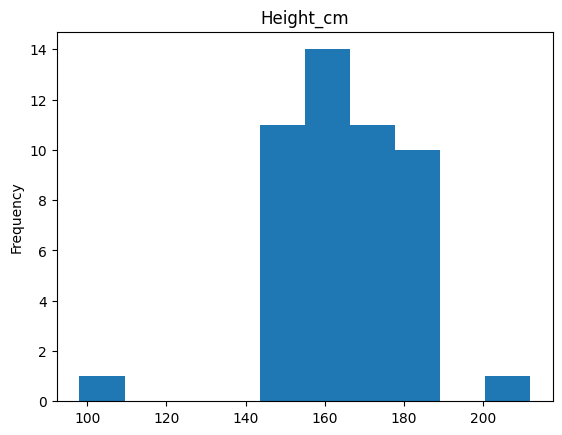

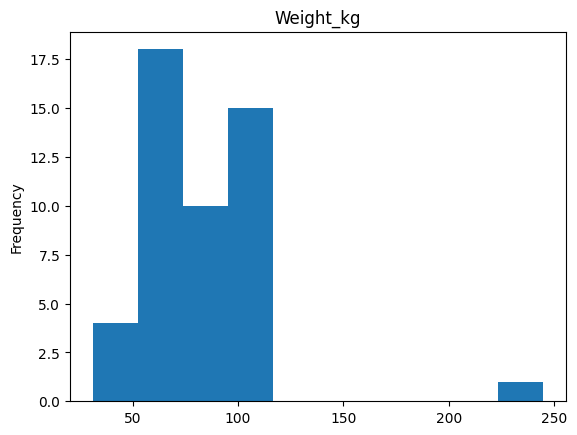

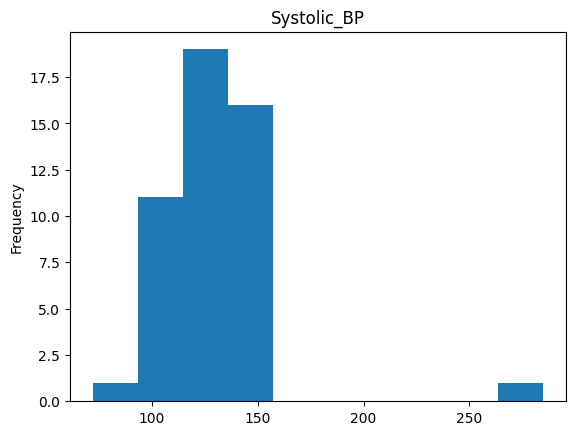

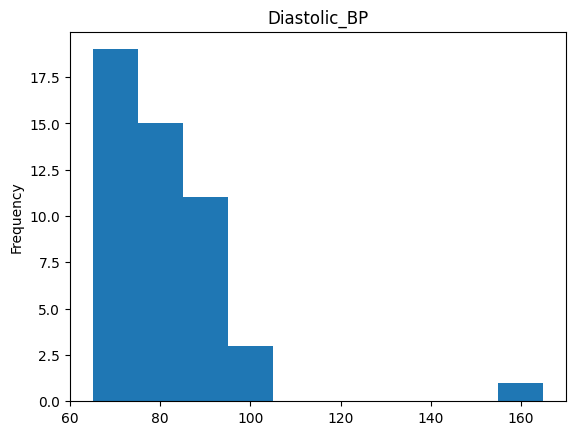

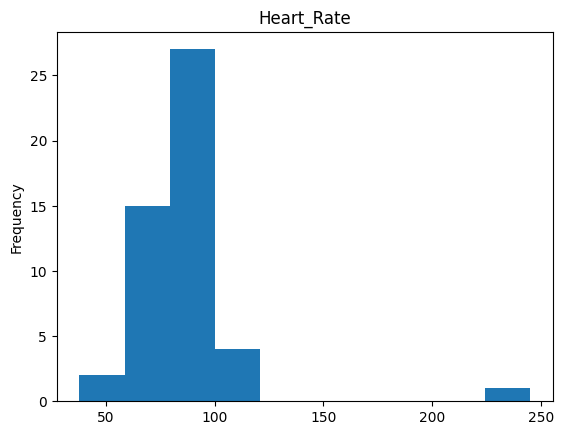

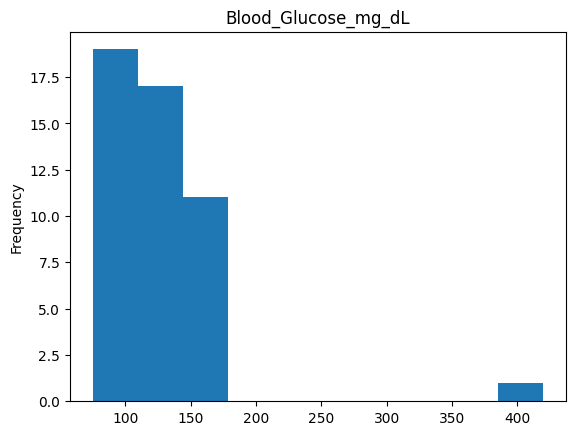

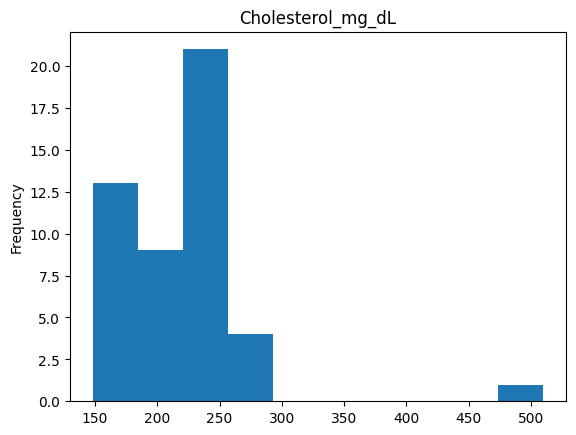

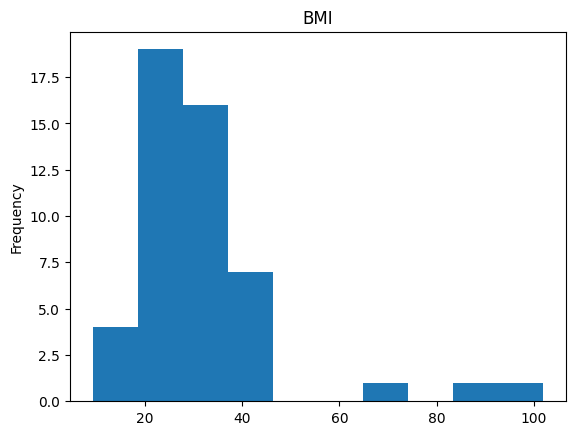

In [ ]:
for column in num:
    data[column].plot(kind="hist", bins=10)
    plt.title(column)
    plt.show()

Task 11: Compare the mean and median of each numerical column containing missing values.

In [ ]:
for column in num:
    mean_value = data[column].mean()
    median_value = data[column].median()

    print(column, mean_value, median_value)

Height_cm 165.4416666666667 164.7
Weight_kg 81.55416666666666 75.45
Systolic_BP 130.27083333333334 123.5
Diastolic_BP 81.06122448979592 77.0
Heart_Rate 87.34693877551021 85.0
Blood_Glucose_mg_dL 125.72916666666667 115.5
Cholesterol_mg_dL 219.125 227.5
BMI 31.814285714285706 28.1


Task 12: Select the suitable imputation method for each numerical column.

In [ ]:
imputation_method = {
    "Height_cm": "mean",
    "Weight_kg": "median",
    "Systolic_BP":"median",
    "Diastolic_BP":"median",
    "Heart_Rate":"mean",
    "Blood_Glucose_mg_dL":"median",
    "Cholesterol_mg_dL":"median",
    "BMI":"median"
    }
print("Height_cm:Mean selected because mean and median are close.")
print("Weight_kg: Median selected because the distribution is skewed.")
print("Systolic_BP:Median selected because mean and median differ noticeably")
print("Diastolic_BP: Median selected because strong high or low values are present")
print("Heart_Rate:Mean selected because mean and median are close")
print("Blood_Glucose_mg_dL:Median selected because strong high or low values are present")
print("Cholesterol_mg_dL:Median selected because the distribution is skewed.")
print("BMI:Median selected because the distribution is skewed.")

Height_cm:Mean selected because mean and median are close.
Weight_kg: Median selected because the distribution is skewed.
Systolic_BP:Median selected because mean and median differ noticeably
Diastolic_BP: Median selected because strong high or low values are present
Heart_Rate:Mean selected because mean and median are close
Blood_Glucose_mg_dL:Median selected because strong high or low values are present
Cholesterol_mg_dL:Median selected because the distribution is skewed.
BMI:Median selected because the distribution is skewed.


Task 13: Replace the missing numerical values using the selected mean or median values.

In [ ]:
value = data["Height_cm"].mean()
data["Height_cm"] = data["Height_cm"].fillna(value)
value = data["Heart_Rate"].mean()
data["Heart_Rate"] = data["Heart_Rate"].fillna(value)
value = data["Weight_kg"].median()
data["Weight_kg"] = data["Weight_kg"].fillna(value)
value = data["Systolic_BP"].median()
data["Systolic_BP"] = data["Systolic_BP"].fillna(value)
value = data["Diastolic_BP"].median()
data["Diastolic_BP"] = data["Diastolic_BP"].fillna(value)
value = data["Blood_Glucose_mg_dL"].median()
data["Blood_Glucose_mg_dL"] = data["Blood_Glucose_mg_dL"].fillna(value)
value = data["Cholesterol_mg_dL"].median()
data["Cholesterol_mg_dL"] = data["Cholesterol_mg_dL"].fillna(value)
value = data["BMI"].median()
data["BMI"] = data["BMI"].fillna(value)
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level
0,PAT001,58,Male,150.900000,63.7,119.0,73.0,64.0,161.0,239.0,28.0,Current,Low
1,PAT002,45,Male,151.000000,60.5,137.0,66.0,93.0,100.0,236.0,26.5,Former,Moderate
2,PAT003,32,Female,165.441667,94.1,105.0,75.0,102.0,129.0,188.0,32.3,Never,Low
3,PAT004,220,Female,153.600000,69.7,127.0,87.0,96.0,108.0,248.0,29.5,Never,Moderate
4,PAT005,25,Female,152.800000,64.7,145.0,88.0,94.0,99.0,235.0,27.7,Never,Moderate


Task 14: Find the mode of each categorical column containing missing values.

In [ ]:
for column in cat:
    print(column, data[column].mode()[0])

Smoking_Status Never
Physical_Activity_Level Moderate


Task 15: Replace the missing categorical values using the respective modes.

In [ ]:
for column in cat:
    mode_value = data[column].mode()[0]
    data[column] = data[column].fillna(mode_value)
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level
0,PAT001,58,Male,150.900000,63.7,119.0,73.0,64.0,161.0,239.0,28.0,Current,Low
1,PAT002,45,Male,151.000000,60.5,137.0,66.0,93.0,100.0,236.0,26.5,Former,Moderate
2,PAT003,32,Female,165.441667,94.1,105.0,75.0,102.0,129.0,188.0,32.3,Never,Low
3,PAT004,220,Female,153.600000,69.7,127.0,87.0,96.0,108.0,248.0,29.5,Never,Moderate
4,PAT005,25,Female,152.800000,64.7,145.0,88.0,94.0,99.0,235.0,27.7,Never,Moderate


Task 16: Verify that no original missing values remain after imputation.

In [ ]:
data.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
Systolic_BP,0
Diastolic_BP,0
Heart_Rate,0
Blood_Glucose_mg_dL,0
Cholesterol_mg_dL,0


Task 17: Check `Age`, `Height_cm`, and `Weight_kg` for unrealistic or suspicious values.

In [ ]:
condition = (
    (data["Age"] < 100) |
    (data["Age"] > 1) |
    (data["Height_cm"] < 27200 ) |
    (data["Height_cm"] > 1)|
     (data["Weight_kg"] < 635 ) |
    (data["Weight_kg"] > 1)
)

data[condition]

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level
0,PAT001,58,Male,150.900000,63.70,119.0,73.0,64.000000,161.0,239.0,28.0,Current,Low
1,PAT002,45,Male,151.000000,60.50,137.0,66.0,93.000000,100.0,236.0,26.5,Former,Moderate
2,PAT003,32,Female,165.441667,94.10,105.0,75.0,102.000000,129.0,188.0,32.3,Never,Low
3,PAT004,220,Female,153.600000,69.70,127.0,87.0,96.000000,108.0,248.0,29.5,Never,Moderate
4,PAT005,25,Female,152.800000,64.70,145.0,88.0,94.000000,99.0,235.0,27.7,Never,Moderate
5,PAT006,67,Female,184.500000,96.80,111.0,89.0,75.000000,115.5,226.0,28.4,Current,Low
6,PAT007,40,Male,98.000000,88.00,148.0,69.0,96.000000,156.0,166.0,91.6,Never,Low
7,PAT008,47,Female,159.400000,100.70,149.0,79.0,101.000000,116.0,252.0,39.6,Former,Low
8,PAT009,70,Male,178.200000,75.45,109.0,78.0,94.000000,115.0,172.0,22.3,Former,Moderate
9,PAT010,76,Female,155.000000,245.00,152.0,81.0,95.000000,129.0,259.0,102.0,Former,Moderate


Task 18: Check `Systolic_BP`, `Diastolic_BP`, and `Heart_Rate` for unrealistic or suspicious values.

In [ ]:
condition = (
    (data["Systolic_BP"] < 90) |
    (data["Systolic_BP"] > 140) |
    (data["Diastolic_BP"] < 60) |
    (data["Diastolic_BP"] > 90) |
    (data["Heart_Rate"] < 60) |
    (data["Heart_Rate"] > 100)
)

data[condition]


,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level
2,PAT003,32,Female,165.441667,94.1,105.0,75.0,102.000000,129.0,188.0,32.3,Never,Low
4,PAT005,25,Female,152.800000,64.7,145.0,88.0,94.000000,99.0,235.0,27.7,Never,Moderate
6,PAT007,40,Male,98.000000,88.0,148.0,69.0,96.000000,156.0,166.0,91.6,Never,Low
7,PAT008,47,Female,159.400000,100.7,149.0,79.0,101.000000,116.0,252.0,39.6,Former,Low
9,PAT010,76,Female,155.000000,245.0,152.0,81.0,95.000000,129.0,259.0,102.0,Former,Moderate
11,PAT012,42,Female,170.900000,74.7,123.5,77.0,101.000000,89.0,232.0,25.6,Current,High
13,PAT014,73,Female,179.500000,76.9,285.0,74.0,81.000000,95.0,214.0,23.9,Current,High
15,PAT016,23,Male,175.600000,94.5,153.0,73.0,66.000000,159.0,227.5,30.6,Current,Low
16,PAT017,51,Female,183.800000,100.9,153.0,77.0,77.000000,126.0,230.0,29.9,Former,Moderate
17,PAT018,51,Female,154.200000,60.8,126.0,165.0,95.000000,145.0,174.0,25.6,Former,Low


Task 19: Check `Blood_Glucose_mg_dL` and `Cholesterol_mg_dL` for unusually high or low values.

In [ ]:
condition = (
    (data["Blood_Glucose_mg_dL"] < 140) |
    (data["Blood_Glucose_mg_dL"] > 70) |
    (data["Cholesterol_mg_dL"] < 200) |
    (data["Cholesterol_mg_dL"] > 60)
)

data[condition]

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level
0,PAT001,58,Male,150.900000,63.70,119.0,73.0,64.000000,161.0,239.0,28.0,Current,Low
1,PAT002,45,Male,151.000000,60.50,137.0,66.0,93.000000,100.0,236.0,26.5,Former,Moderate
2,PAT003,32,Female,165.441667,94.10,105.0,75.0,102.000000,129.0,188.0,32.3,Never,Low
3,PAT004,220,Female,153.600000,69.70,127.0,87.0,96.000000,108.0,248.0,29.5,Never,Moderate
4,PAT005,25,Female,152.800000,64.70,145.0,88.0,94.000000,99.0,235.0,27.7,Never,Moderate
5,PAT006,67,Female,184.500000,96.80,111.0,89.0,75.000000,115.5,226.0,28.4,Current,Low
6,PAT007,40,Male,98.000000,88.00,148.0,69.0,96.000000,156.0,166.0,91.6,Never,Low
7,PAT008,47,Female,159.400000,100.70,149.0,79.0,101.000000,116.0,252.0,39.6,Former,Low
8,PAT009,70,Male,178.200000,75.45,109.0,78.0,94.000000,115.0,172.0,22.3,Former,Moderate
9,PAT010,76,Female,155.000000,245.00,152.0,81.0,95.000000,129.0,259.0,102.0,Former,Moderate


Task 20: Convert height from centimetres to metres and create a temporary column named `Height_m`

In [ ]:
data["Height_m"] = data["Height_cm"] / 100
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level,Height_m
0,PAT001,58,Male,150.900000,63.7,119.0,73.0,64.0,161.0,239.0,28.0,Current,Low,1.509000
1,PAT002,45,Male,151.000000,60.5,137.0,66.0,93.0,100.0,236.0,26.5,Former,Moderate,1.510000
2,PAT003,32,Female,165.441667,94.1,105.0,75.0,102.0,129.0,188.0,32.3,Never,Low,1.654417
3,PAT004,220,Female,153.600000,69.7,127.0,87.0,96.0,108.0,248.0,29.5,Never,Moderate,1.536000
4,PAT005,25,Female,152.800000,64.7,145.0,88.0,94.0,99.0,235.0,27.7,Never,Moderate,1.528000


Task 21: Calculate BMI using height and weight and create `Calculated_BMI`.

In [ ]:
data["Calculated_BMI"] = data["Weight_kg"] / (data["Height_m"] ** 2)
data["Calculated_BMI"] = data["Calculated_BMI"].round(2)
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level,Height_m,Calculated_BMI
0,PAT001,58,Male,150.900000,63.7,119.0,73.0,64.0,161.0,239.0,28.0,Current,Low,1.509000,27.97
1,PAT002,45,Male,151.000000,60.5,137.0,66.0,93.0,100.0,236.0,26.5,Former,Moderate,1.510000,26.53
2,PAT003,32,Female,165.441667,94.1,105.0,75.0,102.0,129.0,188.0,32.3,Never,Low,1.654417,34.38
3,PAT004,220,Female,153.600000,69.7,127.0,87.0,96.0,108.0,248.0,29.5,Never,Moderate,1.536000,29.54
4,PAT005,25,Female,152.800000,64.7,145.0,88.0,94.0,99.0,235.0,27.7,Never,Moderate,1.528000,27.71


Task 22: Calculate the absolute difference between `BMI` and `Calculated_BMI`.

In [ ]:
data["BMI_Difference"] = (data["BMI"] - data["Calculated_BMI"]).abs()
data["BMI_Difference"] = data["BMI_Difference"].round(2)
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level,Height_m,Calculated_BMI,BMI_Difference
0,PAT001,58,Male,150.900000,63.7,119.0,73.0,64.0,161.0,239.0,28.0,Current,Low,1.509000,27.97,0.03
1,PAT002,45,Male,151.000000,60.5,137.0,66.0,93.0,100.0,236.0,26.5,Former,Moderate,1.510000,26.53,0.03
2,PAT003,32,Female,165.441667,94.1,105.0,75.0,102.0,129.0,188.0,32.3,Never,Low,1.654417,34.38,2.08
3,PAT004,220,Female,153.600000,69.7,127.0,87.0,96.0,108.0,248.0,29.5,Never,Moderate,1.536000,29.54,0.04
4,PAT005,25,Female,152.800000,64.7,145.0,88.0,94.0,99.0,235.0,27.7,Never,Moderate,1.528000,27.71,0.01


Task 23: Display records where `BMI_Difference` is greater than 1.

In [ ]:
data[data["BMI_Difference"] > value]
data.loc[ data["BMI_Difference"] > value, ["Patient_ID", "BMI", "Calculated_BMI", "BMI_Difference"]]

,Patient_ID,BMI,Calculated_BMI,BMI_Difference
49,PAT050,74.0,30.29,43.71


Task 24: Create box plots for the numerical health-measurement columns.

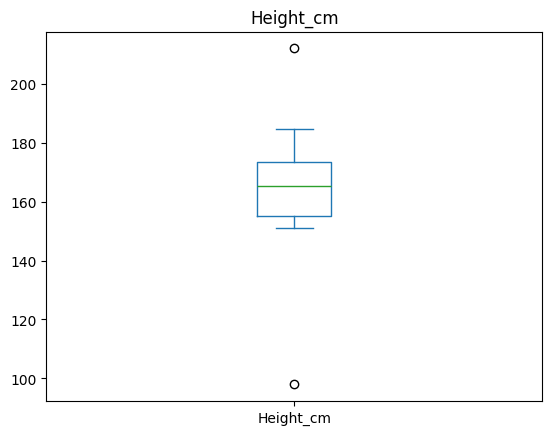

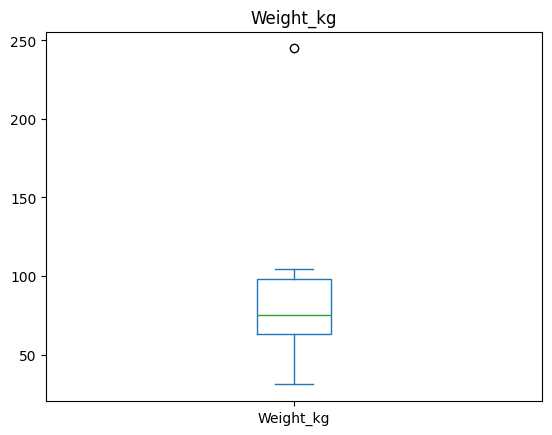

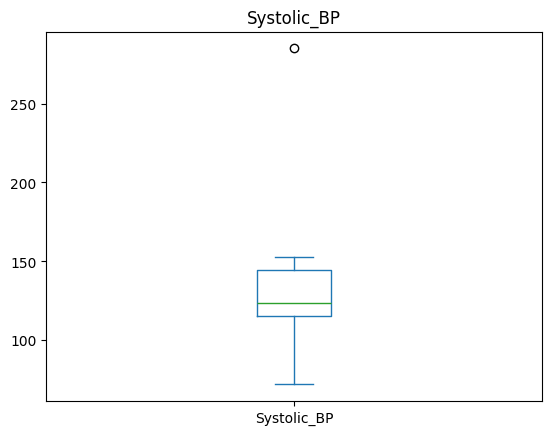

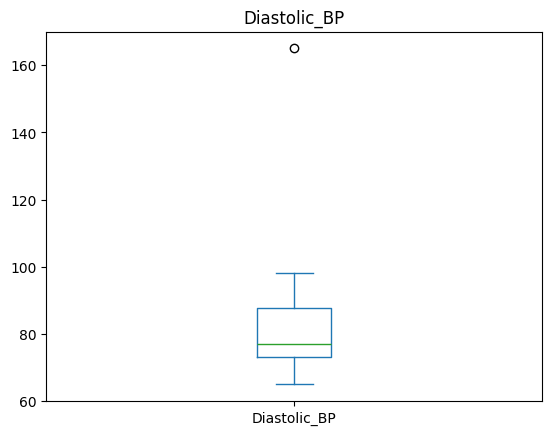

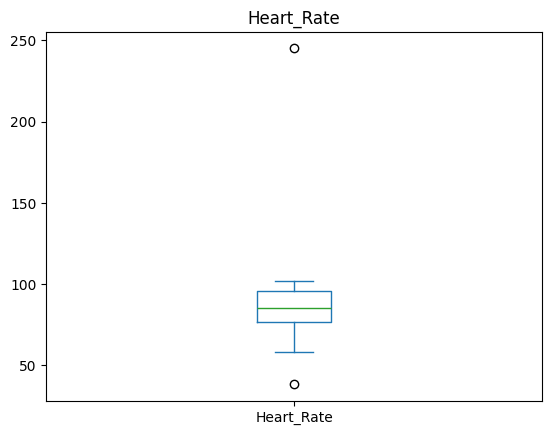

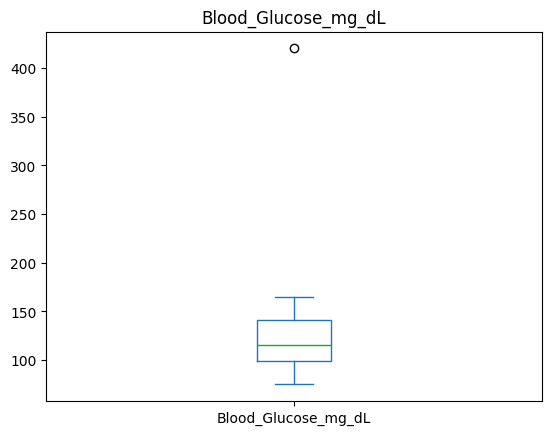

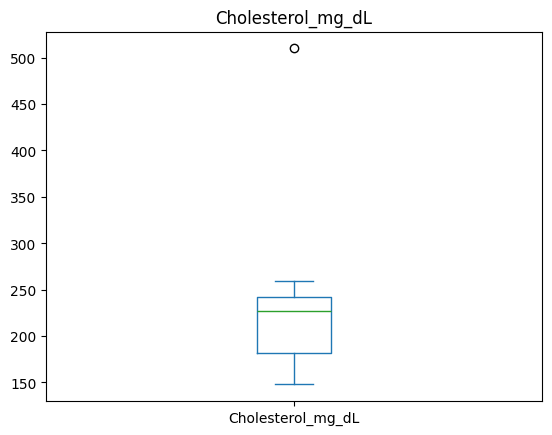

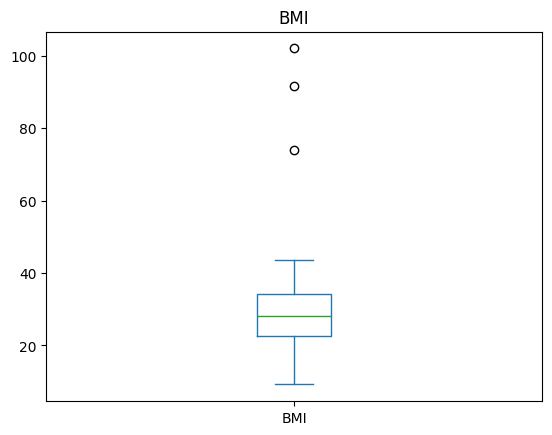

In [ ]:
for column in num:
    data[column].plot(kind="box")
    plt.title(column)
    plt.show()


Task 25: Calculate Q1, Q3, and IQR for each selected numerical column.*

In [ ]:
for column in num:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    print(column, Q1, Q3, IQR)

Height_cm 155.1 173.525 18.42500000000001
Weight_kg 63.1 98.125 35.025
Systolic_BP 115.25 144.25 29.0
Diastolic_BP 73.0 87.75 14.75
Heart_Rate 76.25 95.75 19.5
Blood_Glucose_mg_dL 99.25 141.25 42.0
Cholesterol_mg_dL 182.0 241.75 59.75
BMI 22.7 34.2 11.500000000000004


Task 26: Calculate the lower and upper outlier limits for each selected numerical column.

In [ ]:
outlier_limits = {}
for column in num:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outlier_limits[column] = {
        "Lower_Limit": lower_limit,
        "Upper_Limit": upper_limit
    }
print(outlier_limits)

{'Height_cm': {'Lower_Limit': np.float64(127.46249999999998), 'Upper_Limit': np.float64(201.16250000000002)}, 'Weight_kg': {'Lower_Limit': np.float64(10.562500000000007), 'Upper_Limit': np.float64(150.6625)}, 'Systolic_BP': {'Lower_Limit': np.float64(71.75), 'Upper_Limit': np.float64(187.75)}, 'Diastolic_BP': {'Lower_Limit': np.float64(50.875), 'Upper_Limit': np.float64(109.875)}, 'Heart_Rate': {'Lower_Limit': np.float64(47.0), 'Upper_Limit': np.float64(125.0)}, 'Blood_Glucose_mg_dL': {'Lower_Limit': np.float64(36.25), 'Upper_Limit': np.float64(204.25)}, 'Cholesterol_mg_dL': {'Lower_Limit': np.float64(92.375), 'Upper_Limit': np.float64(331.375)}, 'BMI': {'Lower_Limit': np.float64(5.449999999999992), 'Upper_Limit': np.float64(51.45000000000001)}}


Task 27: Identify and count the outliers present in each selected numerical column.

In [ ]:
for column in num:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]

    print(f"{column}: {len(outliers)} outlier(s)")

Height_cm: 2 outlier(s)
Weight_kg: 1 outlier(s)
Systolic_BP: 1 outlier(s)
Diastolic_BP: 1 outlier(s)
Heart_Rate: 2 outlier(s)
Blood_Glucose_mg_dL: 1 outlier(s)
Cholesterol_mg_dL: 1 outlier(s)
BMI: 3 outlier(s)


Task 28: Display the complete patient records containing at least one detected outlier.

In [ ]:
outlier_conditions = pd.DataFrame(index=data.index)
outlier_conditions[column] = (
    (data[column] < lower_limit) |
    (data[column] > upper_limit)
)
data[outlier_conditions.any(axis=1)]

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level,Height_m,Calculated_BMI,BMI_Difference
6,PAT007,40,Male,98.0,88.0,148.0,69.0,96.0,156.0,166.0,91.6,Never,Low,0.980,91.63,0.03
9,PAT010,76,Female,155.0,245.0,152.0,81.0,95.0,129.0,259.0,102.0,Former,Moderate,1.550,101.98,0.02
49,PAT050,75,Female,171.4,89.0,137.0,92.0,93.0,132.0,259.0,74.0,Never,High,1.714,30.29,43.71


Task 29: Treat clearly invalid values and update the BMI column.

In [ ]:
data.loc[condition, "Calculated_BMI"] = pd.NA
data["Calculated_BMI"] = data["Calculated_BMI"].fillna(
    data["Calculated_BMI"].median()
)
data["Calculated_BMI"] = data["Calculated_BMI"].clip(
    lower=lower_limit,
    upper=upper_limit
)
data["Calculated_BMI"] = data["BMI"]
data.drop(
    columns=[ "Height_m","Calculated_BMI","BMI_Difference"],
    inplace=True
)
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Glucose_mg_dL,Cholesterol_mg_dL,BMI,Smoking_Status,Physical_Activity_Level
0,PAT001,58,Male,150.900000,63.7,119.0,73.0,64.0,161.0,239.0,28.0,Current,Low
1,PAT002,45,Male,151.000000,60.5,137.0,66.0,93.0,100.0,236.0,26.5,Former,Moderate
2,PAT003,32,Female,165.441667,94.1,105.0,75.0,102.0,129.0,188.0,32.3,Never,Low
3,PAT004,220,Female,153.600000,69.7,127.0,87.0,96.0,108.0,248.0,29.5,Never,Moderate
4,PAT005,25,Female,152.800000,64.7,145.0,88.0,94.0,99.0,235.0,27.7,Never,Moderate


Task 30: Validate and save the final cleaned dataset.

In [ ]:
# Task 30: Validate and Save the Final Dataset

# 1. Check missing values
print("Missing Values:")
print(data.isnull().sum())

print("\nDuplicate Records:")
print(data.duplicated().sum())

print("\nFinal Shape:")
print(data.shape)

print("\nDescriptive Statistics:")
print(data.describe())

print("\nTop 5 Cleaned Records:")
print(data.head())

data.to_csv("patient_health_screening_cleaned.csv", index=False)

print("\nThe cleaned dataset has been saved as 'patient_health_screening_cleaned.csv'.")

Missing Values:
Patient_ID                 0
Age                        0
Gender                     0
Height_cm                  0
Weight_kg                  0
Systolic_BP                0
Diastolic_BP               0
Heart_Rate                 0
Blood_Glucose_mg_dL        0
Cholesterol_mg_dL          0
BMI                        0
Smoking_Status             0
Physical_Activity_Level    0
dtype: int64

Duplicate Records:
0

Final Shape:
(50, 13)

Descriptive Statistics:
              Age   Height_cm  Weight_kg  Systolic_BP  Diastolic_BP  \
count   50.000000   50.000000    50.0000     50.00000     50.000000   
mean    54.240000  165.441667    81.3100    130.00000     80.980000   
std     30.030298   15.873053    30.0128     27.98159     15.398768   
min     21.000000   98.000000    31.0000     72.00000     65.000000   
25%     35.500000  155.100000    63.1000    115.25000     73.000000   
50%     52.000000  165.441667    75.4500    123.50000     77.000000   
75%     67.000000  173.5250